In [69]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.nn.utils import weight_norm


import numpy as np 
import matplotlib.pyplot as plt 
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

In [70]:
class CausalCNN(nn.Module):
    def __init__(
            self,
            in_ch: int = 1,
            hidden: int = 16,
            kernel: int = 3,
            num_layers: int = 6,
            out_size: int = 24,
            verbose: bool = False,
    ):
        super().__init__()
        self.kernel = kernel
        self.verbose = verbose
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            in_c = in_ch if i == 0 else hidden
            self.convs.append(nn.Conv1d(in_c, hidden, kernel))
        self.head = nn.Linear(hidden, out_size)

    @property
    def receptive_field(self) -> int:
        return 1 + (self.kernel - 1) * len(self.convs)

    def forward(self, x):
        # x: (batch, in_ch, time)
        pad = self.kernel - 1
        for i, conv in enumerate(self.convs):
            x = F.pad(x, (pad, 0))
            x = F.relu(conv(x))
            if self.verbose:
                print(f"layer {i}: {x.shape}")
        x = x[:, :, -1]
        return self.head(x)

# causal cnn with dilation 
class CausalCNNDilated(nn.Module): 
    def __init__(
            self, 
            in_ch: int = 1, 
            hidden: int = 16, 
            kernel: int = 3, 
            dilations: tuple = (1, 2, 4, 8, 16), 
            out_size: int = 24,
            verbose: bool = False
    ): 
        super().__init__() 
        self.kernel = kernel 
        self.dilations = dilations 
        self.verbose = verbose 
        self.convs = nn.ModuleList() 
        for i, d in enumerate(dilations): 
            in_c = in_ch if i == 0 else hidden 
            self.convs.append(nn.Conv1d(in_c, hidden, kernel, dilation=d)) 
        self.head = nn.Linear(hidden, out_size) 
    
    def forward(self, x): 
        for d, conv in zip(self.dilations, self.convs): 
            pad = (self.kernel - 1) * d # pad scales with dilations 
            x = F.pad(x, (pad, 0)) 
            x = F.relu(conv(x)) 
            if self.verbose: 
                print(f"after conv (d={d}): {x.shape}") 
        x = x[:, :, -1] 
        return self.head(x)


In [71]:
# Bare TCN 
class TCN(nn.Module): 
    def __init__(
            self, 
            in_ch: int = 1, 
            hidden: int = 16, 
            kernel: int = 3, 
            dilations: tuple = (1, 2, 4, 8 ,16), 
            verbose: bool = False,
            out_size: int = 24
    ): 
        super().__init__() 
        self.kernel = kernel 
        self.dilations = dilations 
        self.verbose = verbose 
        self.convs = nn.ModuleList() 
        # 1x1 projections for layer 0 only (in_ch -> hidden mismatch) 
        self.skip_proj = nn.Conv1d(in_ch, hidden, kernel_size=1) if in_ch != hidden else None 
        for i, d in enumerate(dilations): 
            in_c = in_ch if i == 0 else hidden 
            self.convs.append(nn.Conv1d(in_c, hidden, kernel, dilation=d)) 
        self.head = nn.Linear(hidden, out_size) 
    
    @property 
    def receptive_field(self) -> int: 
        return 1 + (self.kernel - 1) * sum(self.dilations) 
    
    def assert_receptive_field(self, x): 
        window = x.shape[-1] 
        assert window >= self.receptive_field, (
            f"Window={window} < RF={self.receptive_field}"
            "Deeper layers will convolve mostly over padding zeros."
            "Increase window or reduce dilations"
        ) 

    def forward(self, x): 
        self.assert_receptive_field(x)
        for i, (d, conv) in enumerate(zip(self.dilations, self.convs)): 
            pad = (self.kernel - 1) * d 
            x_padded = F.pad(x, (pad, 0)) 
            out = F.relu(conv(x_padded)) 

            # residual connections 
            if i == 0 and self.skip_proj is not None: 
                residual = self.skip_proj(x) 
            else: 
                residual = x
            x = out + residual 
            if self.verbose: 
                print(f"after conv (d={d}): {x.shape}") 
        x = x[:, :, -1]
        return self.head(x)

In [73]:
from datetime import datetime 
def train_test_loop(model, train_loader, test_loader, lr=1e-3, epochs=2):
    start = datetime.now()
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    elapsed = (datetime.now() - start).total_seconds()
    print(f"Training time: {elapsed:.1f}s")

    model.eval()
    test_loss = 0.0
    test_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb).item()
            test_loss += loss
            test_losses.append(loss)
    test_mse = test_loss / len(test_loader)
    print(f"Test MSE: {test_mse:.6f}")
    return test_mse, np.array(test_losses)


In [74]:
# Ported from https://github.com/locuslab/TCN

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class FullTCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2, out_size=24):
        super().__init__()
        self.tcn = TemporalConvNet(num_inputs, num_channels, kernel_size, dropout)
        self.head = nn.Linear(num_channels[-1], out_size)

    def forward(self, x):
        # x: (batch, num_inputs, time)
        out = self.tcn(x) # (batch, num_channels[-1], time)
        out = out[:, :, -1] # last timestep: (batch, num_channels[-1])
        return self.head(out) # (batch, out_size)

In [75]:
df = pd.read_csv("./data/PJME_hourly.csv", parse_dates=["Datetime"]).sort_values("Datetime").reset_index(drop=True) 
print(df.shape)
print(df.head()) 
print(df["Datetime"].min(), "->", df["Datetime"].max())

(145366, 2)
             Datetime  PJME_MW
0 2002-01-01 01:00:00  30393.0
1 2002-01-01 02:00:00  29265.0
2 2002-01-01 03:00:00  28357.0
3 2002-01-01 04:00:00  27899.0
4 2002-01-01 05:00:00  28057.0
2002-01-01 01:00:00 -> 2018-08-03 00:00:00


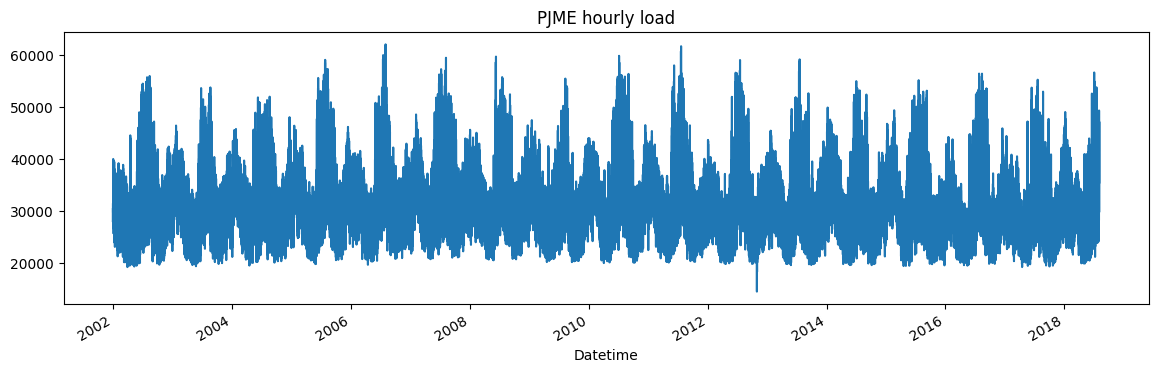

In [76]:
df.set_index("Datetime")["PJME_MW"].plot(figsize=(14,4)) 
plt.title("PJME hourly load")
plt.show()

In [77]:
def preprocess_data_multichannel(
        df: pd.DataFrame,
        window: int = 168,
        horizon: int = 24,
        train_test_split: float = 0.8
):
    """
    Multi-channel input:
      ch 0: load (z-scored)
      ch 1: hour-of-day sin
      ch 2: hour-of-day cos
      ch 3: day-of-week sin
      ch 4: day-of-week cos
      ch 5: month sin
      ch 6: month cos
    """
    dt = pd.to_datetime(df["Datetime"])
    hour = dt.dt.hour.values
    dow = dt.dt.dayofweek.values
    month = dt.dt.month.values

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    dow_sin = np.sin(2 * np.pi * dow / 7)
    dow_cos = np.cos(2 * np.pi * dow / 7)
    month_sin = np.sin(2 * np.pi * (month - 1) / 12)
    month_cos = np.cos(2 * np.pi * (month - 1) / 12)

    load = df["PJME_MW"].to_numpy().astype(np.float32)

    features = np.stack([
        load,
        hour_sin, hour_cos,
        dow_sin, dow_cos,
        month_sin, month_cos,
    ], axis=0).astype(np.float32) # shape (7, T)

    features_t = torch.from_numpy(features) # (7, T)

    # Build windows: (T - window - horizon + 1, 7, window+horizon)
    # unfold creates (7, n_windows, window+horizon), permute to put windows first
    windows = features_t.unfold(1, window + horizon, 1).permute(1, 0, 2)
    # shape: (n_windows, 7, window+horizon)

    split = int(train_test_split * len(windows))
    full_train = windows[:split]
    full_test = windows[split:]

    train_load_inputs = full_train[:, 0, :window]    # (n_train, window)
    mean = train_load_inputs.mean()
    std = train_load_inputs.std()
    print(f"Load train mean: {mean.item():.2f}, std: {std.item():.2f}")

    full_train_z = full_train.clone()
    full_test_z = full_test.clone()
    full_train_z[:, 0] = (full_train[:, 0] - mean) / std
    full_test_z[:, 0] = (full_test[:, 0] - mean) / std

    X_train = full_train_z[:, :, :window] # (n_train, 7, window)
    Y_train = full_train_z[:, 0, window:] # (n_train, horizon) — load only
    X_test = full_test_z[:, :, :window]
    Y_test = full_test_z[:, 0, window:]

    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
    print(f"X_test:  {X_test.shape}, Y_test:  {Y_test.shape}")

    train_ds = TensorDataset(X_train, Y_train)
    test_ds = TensorDataset(X_test, Y_test)
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    return train_loader, test_loader, mean.item(), std.item()

def preprocess_data(data, window: int = 168, horizon: int = 24, train_test_split: float = 0.8):
    """Single-channel PJME preprocessing (z-scored load only)."""
    data_tensor = torch.from_numpy(data).float()
    windows = data_tensor.unfold(0, window + horizon, 1) # (N, window+horizon)

    split = int(train_test_split * len(windows))
    full_train = windows[:split]
    full_test = windows[split:]

    # Z-score using train inputs only
    train_inputs = full_train[:, :window]
    mean = train_inputs.mean()
    std = train_inputs.std()
    print(f"Train mean: {mean.item():.2f}, std: {std.item():.2f}")

    full_train_z = (full_train - mean) / std
    full_test_z = (full_test - mean) / std

    X_train = full_train_z[:, :window].unsqueeze(1) # (n_train, 1, window)
    Y_train = full_train_z[:, window:] # (n_train, horizon)
    X_test = full_test_z[:, :window].unsqueeze(1)
    Y_test = full_test_z[:, window:]

    print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
    print(f"X_test:  {X_test.shape}, Y_test:  {Y_test.shape}")

    train_ds = TensorDataset(X_train, Y_train)
    test_ds = TensorDataset(X_test, Y_test)
    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    return train_loader, test_loader, mean.item(), std.item()


train_loader_7ch, test_loader_7ch, mean, std = preprocess_data_multichannel(
    df, window=168, horizon=24
)

Load train mean: 32330.68, std: 6435.77
X_train: torch.Size([116140, 7, 168]), Y_train: torch.Size([116140, 24])
X_test:  torch.Size([29035, 7, 168]), Y_test:  torch.Size([29035, 24])


In [78]:

train_loader_1ch, test_loader_1ch, mean, std = preprocess_data(
    df['PJME_MW'].to_numpy(), window=168, horizon=24
)

Train mean: 32330.68, std: 6435.77
X_train: torch.Size([116140, 1, 168]), Y_train: torch.Size([116140, 24])
X_test:  torch.Size([29035, 1, 168]), Y_test:  torch.Size([29035, 24])


In [79]:
def train_test_with_preds(model, train_loader, test_loader, lr=1e-3, epochs=2):
    test_mse, test_losses = train_test_loop(model, train_loader, test_loader, lr, epochs)
    
    # Collect predictions
    model.eval()
    preds_all, actuals_all = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds_all.append(model(xb))
            actuals_all.append(yb)
    preds_all = torch.cat(preds_all).numpy()
    actuals_all = torch.cat(actuals_all).numpy()
    return test_mse, preds_all, actuals_all

# bare tcn 
torch.manual_seed(42)
m1 = TCN(in_ch=1, hidden=16, kernel=3, dilations=(1,2,4,8,16,32), out_size=24)
mse_1, preds_bare_1ch, actuals_bare_1ch = train_test_with_preds(m1, train_loader_1ch, test_loader_1ch)

# bare tcn multichannel 
torch.manual_seed(42)
m2 = TCN(in_ch=7, hidden=16, kernel=3, dilations=(1,2,4,8,16,32), out_size=24)
mse_2, preds_bare_7ch, actuals_bare_7ch = train_test_with_preds(m2, train_loader_7ch, test_loader_7ch)

# bull tcn 
torch.manual_seed(42)
m3 = FullTCN(num_inputs=7, num_channels=[64]*5, kernel_size=3, dropout=0.2, out_size=24)
mse_3, preds_full_7ch, actuals_full_7ch = train_test_with_preds(m3, train_loader_7ch, test_loader_7ch)

Training time: 22.7s
Test MSE: 0.131310
Training time: 23.4s
Test MSE: 0.098491


C:\Users\Jay\AppData\Roaming\Python\Python312\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Training time: 203.1s
Test MSE: 0.096904


In [80]:
# causal cnn 
torch.manual_seed(42)
m_causal = CausalCNN(in_ch=1, hidden=16, kernel=3, num_layers=6, out_size=24)
mse_causal, preds_causal_1ch, actuals_causal_1ch = train_test_with_preds(
    m_causal, train_loader_1ch, test_loader_1ch
)

# dilated causal cnn 
torch.manual_seed(42)
m_dilated = CausalCNNDilated(in_ch=1, hidden=16, kernel=3, dilations=(1,2,4,8,16,32), out_size=24)
mse_dilated, preds_dilated_1ch, actuals_dilated_1ch = train_test_with_preds(
    m_dilated, train_loader_1ch, test_loader_1ch
)

Training time: 20.5s
Test MSE: 0.203643
Training time: 25.7s
Test MSE: 0.145281


In [81]:
def per_window_corr(preds, actuals):
    return np.array([np.corrcoef(preds[i], actuals[i])[0, 1] for i in range(len(preds))])

def summarize(name, preds, actuals, std):
    rmse_mw = np.sqrt(((preds - actuals) ** 2).mean()) * std
    corr = per_window_corr(preds, actuals)
    print(f"{name:30s}  RMSE: {rmse_mw:.0f} MW   |   "
          f"pred mean: {preds.mean():+.3f}, std: {preds.std():.3f}   |   "
          f"corr mean: {corr.mean():.3f}, frac>0.8: {(corr > 0.8).mean():.1%}")

print(f"{'Actuals z-stats':30s}  mean: {actuals_full_7ch.mean():+.3f}, std: {actuals_full_7ch.std():.3f}")
print()
summarize("CausalCNN (no dilation)", preds_causal_1ch,  actuals_causal_1ch,  std)
summarize("CausalCNN (dilated)", preds_dilated_1ch, actuals_dilated_1ch, std)
summarize("Bare TCN, 1ch (+residual)", preds_bare_1ch, actuals_bare_1ch, std)
summarize("Bare TCN, 7ch (+features)", preds_bare_7ch, actuals_bare_7ch, std)
summarize("Full TCN, 7ch (+bells)", preds_full_7ch, actuals_full_7ch, std)

print(f"\n{'Seasonal naïve baseline':30s}  RMSE: 4670 MW")

Actuals z-stats                 mean: -0.194, std: 1.008

CausalCNN (no dilation)         RMSE: 2901 MW   |   pred mean: -0.118, std: 0.906   |   corr mean: 0.868, frac>0.8: 80.7%
CausalCNN (dilated)             RMSE: 2452 MW   |   pred mean: -0.091, std: 0.939   |   corr mean: 0.924, frac>0.8: 91.7%
Bare TCN, 1ch (+residual)       RMSE: 2331 MW   |   pred mean: -0.155, std: 0.944   |   corr mean: 0.922, frac>0.8: 91.5%
Bare TCN, 7ch (+features)       RMSE: 2016 MW   |   pred mean: -0.186, std: 0.967   |   corr mean: 0.943, frac>0.8: 95.8%
Full TCN, 7ch (+bells)          RMSE: 1998 MW   |   pred mean: -0.120, std: 0.993   |   corr mean: 0.955, frac>0.8: 96.9%

Seasonal naïve baseline         RMSE: 4670 MW


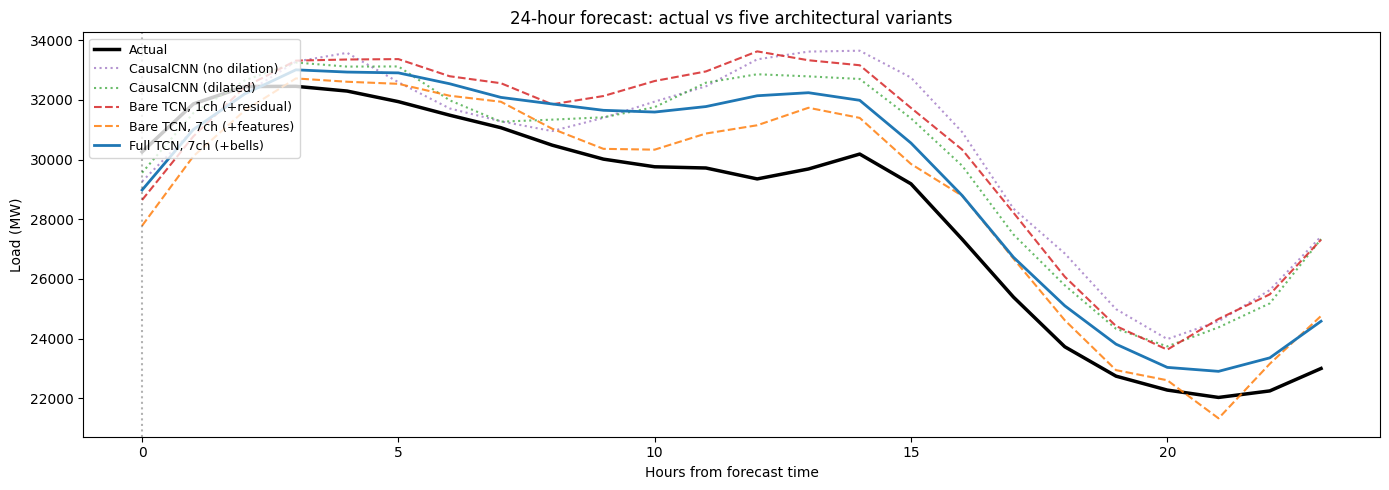

In [82]:
sample_idx = 0  # pick any test window

fig, ax = plt.subplots(figsize=(14, 5))
t_forecast = np.arange(0, 24)

actual_mw = actuals_full_7ch[sample_idx] * std + mean
ax.plot(t_forecast, actual_mw, color="black", linewidth=2.5, label="Actual")

ax.plot(t_forecast, preds_causal_1ch[sample_idx] * std + mean,
        color="C4", linewidth=1.5, linestyle=":", alpha=0.7, label="CausalCNN (no dilation)")
ax.plot(t_forecast, preds_dilated_1ch[sample_idx] * std + mean,
        color="C2", linewidth=1.5, linestyle=":", alpha=0.7, label="CausalCNN (dilated)")
ax.plot(t_forecast, preds_bare_1ch[sample_idx] * std + mean,
        color="C3", linewidth=1.5, linestyle="--", alpha=0.85, label="Bare TCN, 1ch (+residual)")
ax.plot(t_forecast, preds_bare_7ch[sample_idx] * std + mean,
        color="C1", linewidth=1.5, linestyle="--", alpha=0.85, label="Bare TCN, 7ch (+features)")
ax.plot(t_forecast, preds_full_7ch[sample_idx] * std + mean,
        color="C0", linewidth=2, label="Full TCN, 7ch (+bells)")

ax.axvline(0, color="black", linestyle=":", alpha=0.3)
ax.set_xlabel("Hours from forecast time")
ax.set_ylabel("Load (MW)")
ax.set_title("24-hour forecast: actual vs five architectural variants")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

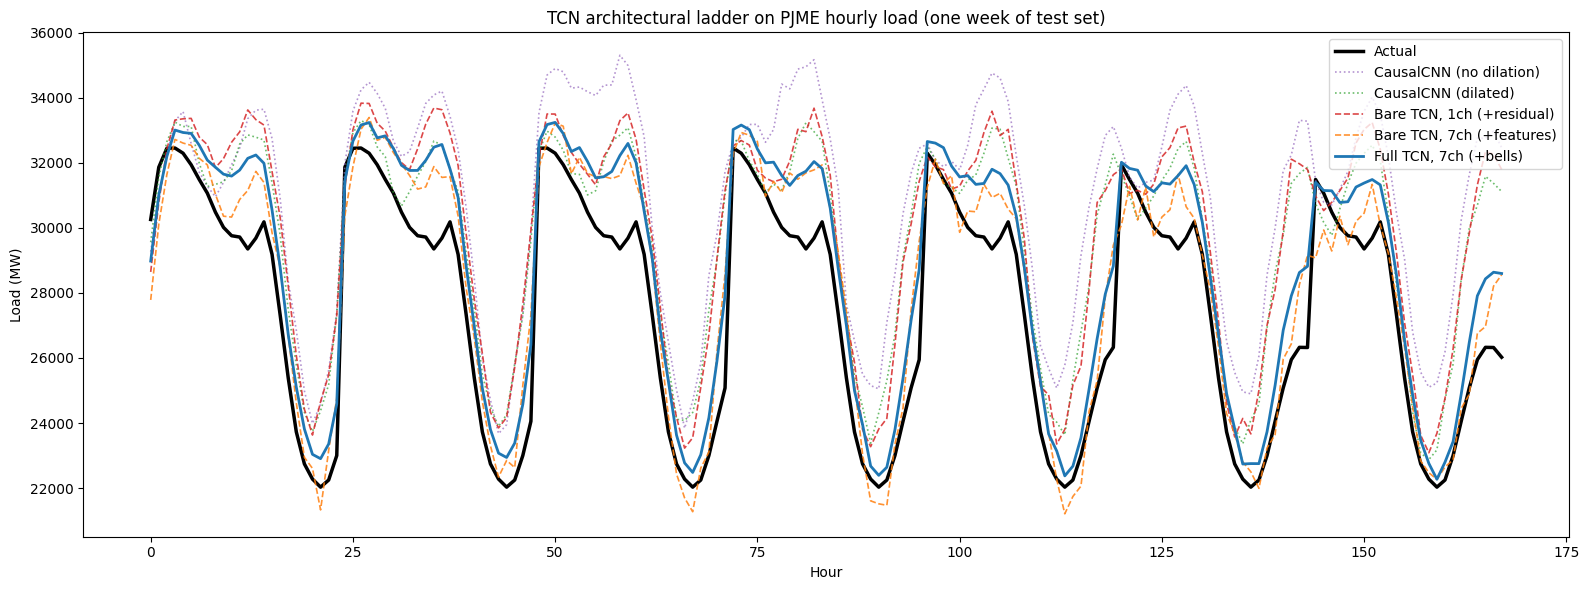

In [84]:
n_blocks = 7   
pred_causal_1ch_7d = (preds_causal_1ch[:n_blocks] * std + mean).flatten()
pred_dilated_1ch_7d = (preds_dilated_1ch[:n_blocks] * std + mean).flatten()
pred_bare_1ch_7d = (preds_bare_1ch[:n_blocks] * std + mean).flatten()
pred_bare_7ch_7d = (preds_bare_7ch[:n_blocks] * std + mean).flatten()
pred_full_7ch_7d = (preds_full_7ch[:n_blocks] * std + mean).flatten()
actual_7d = (actuals_full_7ch[:n_blocks] * std + mean).flatten()

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(actual_7d, color="black", linewidth=2.5, label="Actual")
ax.plot(pred_causal_1ch_7d, color="C4", linewidth=1.2, linestyle=":", alpha=0.7, label="CausalCNN (no dilation)")
ax.plot(pred_dilated_1ch_7d, color="C2", linewidth=1.2, linestyle=":", alpha=0.7, label="CausalCNN (dilated)")
ax.plot(pred_bare_1ch_7d, color="C3", linewidth=1.2, linestyle="--", alpha=0.85, label="Bare TCN, 1ch (+residual)")
ax.plot(pred_bare_7ch_7d, color="C1", linewidth=1.2, linestyle="--", alpha=0.85, label="Bare TCN, 7ch (+features)")
ax.plot(pred_full_7ch_7d, color="C0", linewidth=2, label="Full TCN, 7ch (+bells)")

ax.set_title("TCN architectural ladder on PJME hourly load (one week of test set)")
ax.set_xlabel("Hour")
ax.set_ylabel("Load (MW)")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

| Model | RMSE (MW) | Mean correlation | Frac > 0.8 |
|-------|-----------|------------------|------------|
| Seasonal naïve | 4670 | — | — |
| CausalCNN (no dilation) | 2901 | 0.868 | 80.7% |
| CausalCNN (dilated) | 2452 | 0.924 | 91.7% |
| Bare TCN (+residual) | 2331 | 0.922 | 91.5% |
| Bare TCN (+features) | 2016 | 0.943 | 95.8% |
| Full TCN (+bells) | 1998 | 0.955 | 96.9% |

## References
- Bai et al. (2018) — [arxiv.org/abs/1803.01271](https://arxiv.org/abs/1803.01271)
- Reference implementation ported from [github.com/locuslab/TCN](https://github.com/locuslab/TCN)
- Dataset: [Hourly Energy Consumption (PJM)](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)